## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Is there a statistically significant difference in the unit price of clothing items associated with women compared to men — whether measured through product gender labels or buyer gender — and does this pattern hold across two independent retail datasets with different data structures and price measurement approaches?

## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


We hypothesize that female-associated clothing commands a statistically significantly higher unit price than male-associated clothing. This prediction is supported by prior evidence from the NYC DCA report, which found women's clothing to be approximately 8% more expensive than men's on average. We expect this pattern to manifest both in the price tiers female buyers select and in the labeled prices of women's versus men's apparel products.

## Data

### Data overview

Here we load the primary datasets


In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.ticker as ticker

from pathlib import Path
ROOT = Path.cwd()

file1_path = ROOT / "data" / "01-interim" / "cleaned_data.csv"
file2_path = ROOT / "data" / "01-interim" / "retail_sales_dataset_clothing_sales.csv"
RAW  = ROOT / 'data' / '00-raw'
INTERIM   = ROOT / 'data' / '01-interim'
PROCESSED = ROOT / 'data' / '02-processed'

df1 = pd.read_csv(file1_path)
df2 = pd.read_csv(file2_path)

df1.head()

,Unnamed: 0,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,...,Coupon_Status,GST,Date,Offline_Spend,Online_Spend,Month,Coupon_Code,Discount_pct,Product_Gender,Clothing_Type
0,2170,17850.0,M,Chicago,12.0,16682.0,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,...,Not Used,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
1,2171,17850.0,M,Chicago,12.0,16697.0,2019-01-01,GGOEGAAJ073414,Google Men's Short Sleeve Hero Tee Heather,Apparel,...,Clicked,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
2,2172,17850.0,M,Chicago,12.0,16704.0,2019-01-01,GGOEGAPB058615,Google Women's Yoga Jacket Black,Apparel,...,Used,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Women,Outerwear
3,2173,17850.0,M,Chicago,12.0,16706.0,2019-01-01,GGOEGAAB010517,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,...,Clicked,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
4,2174,17850.0,M,Chicago,12.0,16715.0,2019-01-01,GGOEYAFB073115,YouTube Men's Fleece Hoodie Black,Apparel,...,Used,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,Outerwear


### Dataset #1 

To analyze the "T-Shirts & Shirts" category, we filter it down to the specific subset from Dataset #1.

In [71]:
filtered_df1 = df1[df1['Clothing_Type'] == 'T-Shirts & Shirts']
filtered_df1.head()

,Unnamed: 0,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,...,Coupon_Status,GST,Date,Offline_Spend,Online_Spend,Month,Coupon_Code,Discount_pct,Product_Gender,Clothing_Type
0,2170,17850.0,M,Chicago,12.0,16682.0,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,...,Not Used,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
1,2171,17850.0,M,Chicago,12.0,16697.0,2019-01-01,GGOEGAAJ073414,Google Men's Short Sleeve Hero Tee Heather,Apparel,...,Clicked,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
3,2173,17850.0,M,Chicago,12.0,16706.0,2019-01-01,GGOEGAAB010517,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,...,Clicked,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
5,2175,17850.0,M,Chicago,12.0,16716.0,2019-01-01,GGOEGAAJ073415,Google Men's Short Sleeve Hero Tee Heather,Apparel,...,Clicked,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
6,2176,13047.0,M,California,43.0,16682.0,2019-01-01,GGOEYAAB031816,YouTube Men's Short Sleeve Hero Tee Black,Apparel,...,Used,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts


Then, save it to `/02-processed`

In [77]:
filtered_df1.to_csv(PROCESSED / 'xuanye_filtered_t-shirts_data.csv', index=False)

In [52]:
# Separate the prices into two distinct arrays
mens_prices = filtered_df1[filtered_df1['Product_Gender'] == 'Men']['Avg_Price']
womens_prices = filtered_df1[filtered_df1['Product_Gender'] == 'Women']['Avg_Price']

# 1. Welch's T-Test 
# We use equal_var=False because the variances between the two groups might not be the same
# alternative='greater' tests if Women's prices > Men's prices (The Pink Tax hypothesis)
t_stat, p_value_t = stats.ttest_ind(womens_prices, mens_prices, alternative='greater', equal_var=False)

print("\n--- Welch's T-Test ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value_t:.4f}")

# 2. Mann-Whitney U Test
# A non-parametric test that is robust to outliers and non-normal distributions
u_stat, p_value_mw = stats.mannwhitneyu(womens_prices, mens_prices, alternative='greater')

print("\n--- Mann-Whitney U Test ---")
print(f"U-statistic: {u_stat:.4f}")
print(f"P-value: {p_value_mw:.4f}")

# Final Conclusion Logic
alpha = 0.05
if p_value_mw < alpha:
    print("\nConclusion: Reject the null hypothesis. There is statistically significant evidence of a Pink Tax (Women's shirts are more expensive).")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is NO statistically significant evidence of a Pink Tax. In fact, men's shirts may be more expensive.")


--- Welch's T-Test ---
T-statistic: -23.6172
P-value: 1.0000

--- Mann-Whitney U Test ---
U-statistic: 7160399.0000
P-value: 1.0000

Conclusion: Fail to reject the null hypothesis. There is NO statistically significant evidence of a Pink Tax. In fact, men's shirts may be more expensive.


The statistical tests yield a p-value of 1.0. In hypothesis testing (using a standard alpha level of 0.05), a p-value this high means we completely fail to reject the null hypothesis. Statistically speaking, there is zero evidence of a "pink tax" in the T-shirts & Shirts category of this dataset.

### Dataset #2-1
This dataset contains 52,955 transactions from the Google Merchandise Store in 2019. It has a `Product_Category` column, but no built-in clothing sub-category. We recover clothing items using two steps: (1) filter rows where `Product_Category` is `Apparel` or `Headgear`, and (2) extract a product-level gender label from `Product_Description` using keyword matching. This makes the gender signal more direct than Dataset 2 — it reflects what the product is marketed as, not who bought it.

In [53]:
# Load raw Dataset 1
df1_raw = pd.read_csv(RAW / 'file.csv')
print('Raw shape:', df1_raw.shape)
print('Product categories:', df1_raw['Product_Category'].unique())

Raw shape: (52955, 21)
Product categories: <StringArray>
[            'Nest-USA',               'Office',              'Apparel',
                 'Bags',            'Drinkware',            'Lifestyle',
                 'Waze',             'Headgear',                  'Fun',
 'Notebooks & Journals',               'Google',          'Nest-Canada',
              'Bottles',           'Gift Cards',            'More Bags',
            'Backpacks',           'Housewares',              'Android',
                 'Nest',          'Accessories',            'Notebooks']
Length: 21, dtype: str


#### Step 1.1 — Filter to Clothing-Related Categories

We keep only rows where `Product_Category` is `Apparel` or `Headgear`. All other categories (Nest-USA, Office, Drinkware, etc.) are unrelated to clothing and are dropped entirely at this stage.

In [54]:
df1 = df1_raw[df1_raw['Product_Category'].isin(['Apparel', 'Headgear'])].copy() # TODO: change the df name, df1 is used above
print('After category filter:', df1.shape)

After category filter: (18897, 21)


#### Step 1.2 — Drop Rows Missing Critical Fields

We drop any row that is missing `Product_Description`, `Avg_Price`, or `Transaction_ID`, as these are required for gender extraction and price analysis. Non-critical fields (`Coupon_Code`, `Discount_pct`) are filled with sensible defaults rather than dropped, to preserve sample size.

In [55]:
df1.dropna(subset=['Product_Description', 'Avg_Price', 'Transaction_ID'], inplace=True)
df1['Coupon_Code']  = df1['Coupon_Code'].fillna('No Coupon')
df1['Discount_pct'] = df1['Discount_pct'].fillna(0.0)
df1.drop_duplicates(inplace=True)
df1['Transaction_Date'] = pd.to_datetime(df1['Transaction_Date'])
print('After cleaning:', df1.shape)
print('Missing values remaining:\n', df1[['Product_Description','Avg_Price','Transaction_ID']].isnull().sum())

After cleaning: (18897, 21)
Missing values remaining:
 Product_Description    0
Avg_Price              0
Transaction_ID         0
dtype: int64


#### Step 1.3 — Extract Product Gender from Description

We scan each `Product_Description` for gender-specific keywords. The priority order is: Kids keywords first (to avoid 'men' matching 'women'), then 'women', then 'men'. Everything else is labelled `Unisex/Other`. We then keep only `Men` and `Women` rows for analysis, dropping Kids and Unisex because they cannot be used to compare gendered pricing.

In [56]:
def extract_product_gender(description):
    desc = str(description).lower()
    if any(x in desc for x in ['youth', 'toddler', 'infant', 'onesie', 'kids']):
        return 'Kids'
    elif 'women' in desc:
        return 'Women'
    elif 'men' in desc:
        return 'Men'
    else:
        return 'Unisex/Other'

df1['Product_Gender'] = df1['Product_Description'].apply(extract_product_gender)
print('Gender label distribution:')
print(df1['Product_Gender'].value_counts())

Gender label distribution:
Product_Gender
Men             8970
Women           4452
Unisex/Other    3638
Kids            1837
Name: count, dtype: int64


In [57]:
# Keep only Men and Women
adult_clothing = df1[df1['Product_Gender'].isin(['Men', 'Women'])].copy()
print('After keeping Men/Women only:', adult_clothing.shape)

After keeping Men/Women only: (13422, 22)


#### Step 1.4 — Classify Clothing Sub-Category

Within the gendered clothing subset, we further classify each product into a sub-category based on keywords in the description: `T-Shirts & Shirts` (tee, shirt, polo) or `Outerwear` (hoodie, jacket, sweatshirt, pullover, vest). Rows that match neither are labelled `Other` and dropped, since they tend to be accessories or unclassifiable items that would add noise.

In [58]:
def get_clothing_type(desc):
    desc = str(desc).lower()
    if any(w in desc for w in ['tee', 't-shirt', 'shirt', 'polo']):
        return 'T-Shirts & Shirts'
    elif any(w in desc for w in ['hoodie', 'jacket', 'sweatshirt', 'pullover', 'vest', 'softshell']):
        return 'Outerwear'
    else:
        return 'Other'

adult_clothing['Clothing_Type'] = adult_clothing['Product_Description'].apply(get_clothing_type)
d1_clean = adult_clothing[adult_clothing['Clothing_Type'] != 'Other'].copy()

print('Final Dataset 1 shape:', d1_clean.shape)
print(d1_clean.groupby(['Product_Gender', 'Clothing_Type']).size())

Final Dataset 1 shape: (12507, 23)
Product_Gender  Clothing_Type    
Men             Outerwear            1746
                T-Shirts & Shirts    6595
Women           Outerwear             936
                T-Shirts & Shirts    3230
dtype: int64


#### Step 1.5 — Save Interim Dataset 1

We save the cleaned Dataset 1 to `data/02-processed/` so that other team members can load it directly without re-running the cleaning steps above.

In [59]:
d1_clean.to_csv(PROCESSED / 'yilin_d1_online_clothing_clean.csv', index=False)
print('Saved to data/02-processed/yilin_d1_online_clothing_clean.csv')

Saved to data/02-processed/yilin_d1_online_clothing_clean.csv


### Dataset #2-2 — Retail Sales Dataset

This dataset contains 1,000 synthetic retail transactions. It has an explicit `Product Category` column, so filtering to clothing is straightforward. However, it contains no `Product_Description`, so we cannot determine the gender that the product is marketed toward. Instead, we use the buyer's `Gender` as a proxy, under the assumption that female buyers purchase women's clothing and male buyers purchase men's clothing. This is a weaker signal than Dataset 1 and is acknowledged as a key methodological limitation.

In [60]:
# Load raw Dataset 2
df2_raw = pd.read_csv(RAW / 'retail_sales_dataset.csv')
print('Raw shape:', df2_raw.shape)
print('Product categories:', df2_raw['Product Category'].unique())

Raw shape: (1000, 9)
Product categories: <StringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str


#### Step 2.1 — Filter to Clothing and Verify Data Quality

We strip whitespace from the `Product Category` column to prevent silent mismatches, then filter to `Clothing` only. We also confirm there are no missing values, duplicate Transaction IDs, or unexpected values in the `Gender` column.

In [61]:
df2_raw['Product Category'] = df2_raw['Product Category'].str.strip()
d2_clean = df2_raw[df2_raw['Product Category'] == 'Clothing'].copy().reset_index(drop=True)

print('Clothing rows:', len(d2_clean))
print('Missing values:\n', d2_clean.isnull().sum())
print('Duplicate Transaction IDs:', d2_clean['Transaction ID'].duplicated().sum())
print('Gender values:', d2_clean['Gender'].value_counts().to_dict())

Clothing rows: 351
Missing values:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
Duplicate Transaction IDs: 0
Gender values: {'Male': 177, 'Female': 174}


#### Step 2.2 — Engineer Analysis Variables

We add two binary flag variables that will be used in the single-dataset EDA section:

- **`High_Value_Flag`**: 1 if `Price per Unit >= $300`, else 0. Separates budget (50) from premium (500) purchases.
- **`Verified Price per Unit`**: recomputed as `Total Amount / Quantity`. Used as a cross-check — any row where this differs from `Price per Unit` indicates a data error.

In [62]:
d2_clean['High_Value_Flag'] = (d2_clean['Price per Unit'] >= 300).astype(int)
d2_clean['Verified Price per Unit'] = d2_clean['Total Amount'] / d2_clean['Quantity']

inconsistent = d2_clean[d2_clean['Verified Price per Unit'] != d2_clean['Price per Unit']]
print(f'Inconsistent rows: {len(inconsistent)}')  # expect 0

print('High-Value rate by Gender:')
print(d2_clean.groupby('Gender')['High_Value_Flag'].mean().round(3) * 100)

Inconsistent rows: 0
High-Value rate by Gender:
Gender
Female    40.8
Male      36.7
Name: High_Value_Flag, dtype: float64


#### Step 2.3 — Save Interim Dataset 2

We save the cleaned Dataset 2 to `data/02-processed/` for use by other team members.

In [63]:
d2_clean.to_csv(PROCESSED / 'yilin_d2_retail_clothing_clean.csv', index=False)
print('Saved to data/02-processed/yilin_d2_retail_clothing_clean.csv')

Saved to data/02-processed/yilin_d2_retail_clothing_clean.csv


### Dataset #2-3 — Combined Dataset (Aligned Schema)

The two datasets cannot be joined on a shared key — they have no common customer ID, product SKU, or time period. Instead, we align them conceptually: both datasets contain a gender signal for each clothing transaction and a unit price. We extract these into a minimal three-column schema and concatenate vertically.

The `source` column records where each row came from:

- `D1_ProductLabel` — gender derived from product description (more direct)
- `D2_BuyerGender` — gender derived from buyer self-report (proxy assumption)
This combined dataset is **not** a traditional merge. Its purpose is to allow side-by-side comparison of the gender price gap across two independent data sources in a single analysis.

#### Step 3.1 — Load Cleaned Interim Files
We reload from `data/02-processed/` so this section is self-contained and does not depend on re-running the cleaning steps above.

In [64]:
d1 = pd.read_csv(PROCESSED / 'yilin_d1_online_clothing_clean.csv')
d2 = pd.read_csv(PROCESSED / 'yilin_d2_retail_clothing_clean.csv')
print('D1 shape:', d1.shape)
print('D2 shape:', d2.shape)

D1 shape: (12507, 23)
D2 shape: (351, 11)


#### Step 3.2 — Align to Shared Schema

We extract three columns from each dataset and rename them to a common vocabulary:

| Unified field | From Dataset 1 | From Dataset 2 |
|---|---|---|
| `gender_label` | `Product_Gender` (Men/Women) | `Gender` mapped to Men/Women |
| `unit_price` | `Avg_Price` (continuous, $1–$120) | `Price per Unit` (discrete, 5 tiers) |
| `source` | `D1_ProductLabel` | `D2_BuyerGender` |

No other columns are retained in the combined file. Variables that exist in only one dataset (Age, Discount_pct, Location) would create large blocks of NaN if included, and are better analysed within their respective single-dataset sections.

In [65]:
d1_unified = pd.DataFrame({
    'gender_label': d1['Product_Gender'],
    'unit_price':   d1['Avg_Price'],
    'source':       'D1_ProductLabel'
})

d2_unified = pd.DataFrame({
    'gender_label': d2['Gender'].map({'Female': 'Women', 'Male': 'Men'}),
    'unit_price':   d2['Price per Unit'],
    'source':       'D2_BuyerGender'
})

combined = pd.concat([d1_unified, d2_unified], ignore_index=True)
print('Combined shape:', combined.shape)
print()
print(combined.groupby(['source', 'gender_label']).size().rename('count'))

Combined shape: (12858, 3)

source           gender_label
D1_ProductLabel  Men             8341
                 Women           4166
D2_BuyerGender   Men              177
                 Women            174
Name: count, dtype: int64


#### Step 3.3 — Verify and Save Combined Dataset

Before saving, we do a final sanity check: confirm no unexpected gender labels, no missing values, and that the row counts match what we expect from each source.

In [66]:
print('Missing values in combined:\n', combined.isnull().sum())
print('Unique gender labels:', combined['gender_label'].unique())
print('Unique sources:', combined['source'].unique())
print()
print('Row counts by source x gender:')
print(combined.groupby(['source', 'gender_label']).size().rename('count'))

combined.to_csv(PROCESSED / 'yilin_combined_clothing_gender_price.csv', index=False)
print('\nSaved to data/02-processed/yilin_combined_clothing_gender_price.csv')

Missing values in combined:
 gender_label    0
unit_price      0
source          0
dtype: int64
Unique gender labels: <StringArray>
['Men', 'Women']
Length: 2, dtype: str
Unique sources: <StringArray>
['D1_ProductLabel', 'D2_BuyerGender']
Length: 2, dtype: str

Row counts by source x gender:
source           gender_label
D1_ProductLabel  Men             8341
                 Women           4166
D2_BuyerGender   Men              177
                 Women            174
Name: count, dtype: int64

Saved to data/02-processed/yilin_combined_clothing_gender_price.csv


## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - Dataset #1 T-Shirts & Shirts categoty
Before running complex tests, we need to understand the baseline of our data. We will look at the proportion of Men's vs. Women's clothing in this specific category to see if there is a class imbalance.

Overall Percentage of Products by Gender:
Product_Gender
Men      66.69%
Women    33.31%
Name: proportion, dtype: str


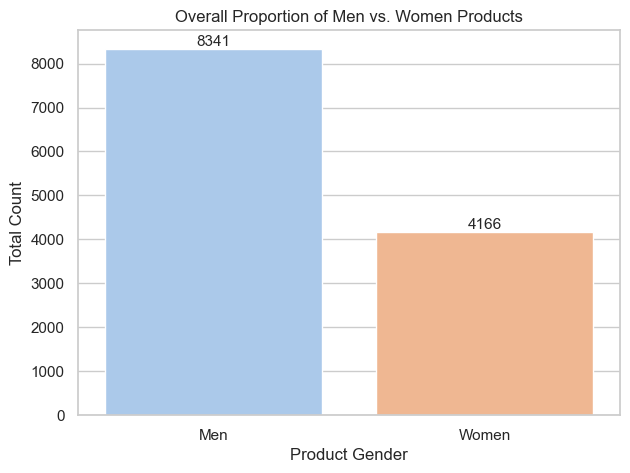

In [74]:
# Calculate the exact percentages
gender_counts = df1['Product_Gender'].value_counts(normalize=True) * 100
print("Overall Percentage of Products by Gender:")
print(gender_counts.round(2).astype(str) + '%')

# Visualize the distribution
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df1, x='Product_Gender', hue='Product_Gender', palette='pastel', legend=False)

plt.title('Overall Proportion of Men vs. Women Products')
plt.xlabel('Product Gender')
plt.ylabel('Total Count')

# Add exact counts on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)

plt.show()

The bar chart reveals a significant class imbalance in our dataset: Men's shirts make up roughly 66.7% of the inventory, while Women's shirts make up about 33.3%, which is exactly a 2:1 ratio. While the sample sizes are unequal, both groups have a sufficiently large sample size ($n > 3000$) to provide immense statistical power.

Next, we will look at the basic descriptive statistics (mean, median, standard deviation) for the prices of men's and women's shirts to see if the "Pink Tax" hypothesis holds up at a surface level.

In [75]:
# Group the filtered data by 'Product_Gender' and calculate summary statistics for 'Avg_Price'
price_summary = filtered_df1.groupby('Product_Gender')['Avg_Price'].describe()

print("\nSummary Statistics for T-Shirts & Shirts Prices by Gender:")
print(price_summary)


Summary Statistics for T-Shirts & Shirts Prices by Gender:
                 count       mean       std  min    25%    50%    75%    max
Product_Gender                                                              
Men             6595.0  13.415375  5.948501  3.4  10.63  13.59  16.99  92.84
Women           3230.0  10.307972  6.211785  3.4   4.80   9.60  15.19  62.99


Based on the output, the mean price for Men's T-Shirts is approximately $13.42, while the mean price for Women's is $10.31. This initial look contradicts the "pink tax" hypothesis, showing that men's shirts are actually priced higher on average.

To understand the spread and shape of the price distributions—which numbers alone might not fully convey—we will visualize the data using a boxplot and a histogram.

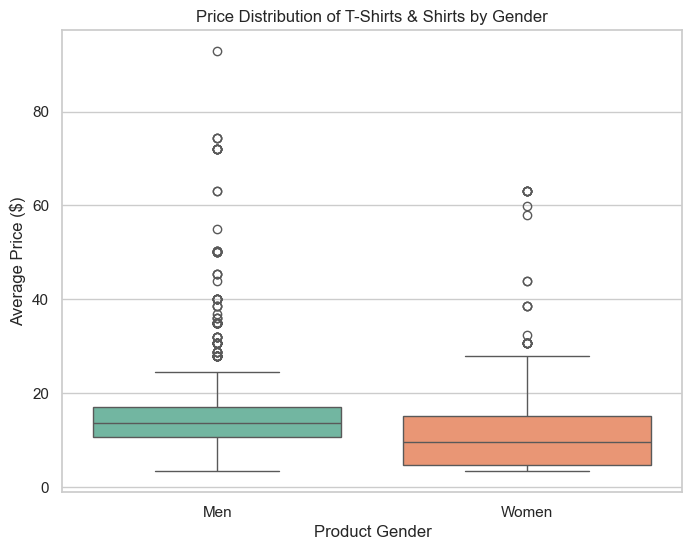

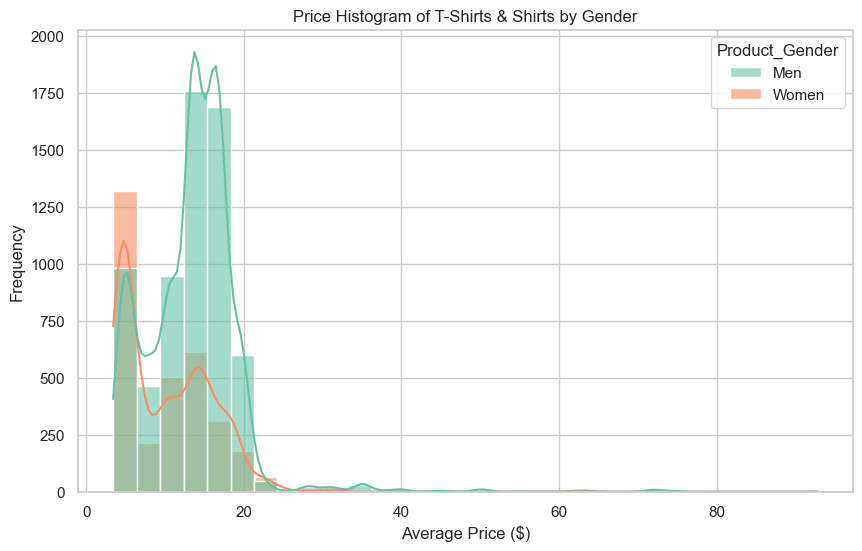

In [76]:
# Set the visual style for seaborn
sns.set_theme(style="whitegrid")

# Create a Boxplot to visualize medians and outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x='Product_Gender', y='Avg_Price', data=filtered_df1, hue='Product_Gender', palette="Set2", legend=False)
plt.title('Price Distribution of T-Shirts & Shirts by Gender')
plt.xlabel('Product Gender')
plt.ylabel('Average Price ($)')
plt.show()

# Create a Histogram to visualize the distribution of prices
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_df1, x='Avg_Price', hue='Product_Gender', kde=True, bins=30, palette="Set2", alpha=0.6)
plt.title('Price Histogram of T-Shirts & Shirts by Gender')
plt.xlabel('Average Price ($)')
plt.ylabel('Frequency')
plt.show()

- **Boxplot**: Visually confirms that the median (the line inside the box) for men's shirts is higher than for women's. It also shows that men have a wider interquartile range and a longer tail of high-priced outliers.

- **Histogram**: Shows that women's shirt prices are heavily right-skewed, meaning most of the shirts are clustered at the lower price points (around $5-$10). Men's prices are more spread out, with a noticeable bump in the $15 range.

#### Section 2 of EDA - Dataset #1 Outerwear category

In [ ]:
# TODO: merge Nicole's part

#### Section 3-1 of EDA - Dataset #1 in the Combined dataset

Overview:

This section explores Dataset 1 (Online Shopping, Google Merchandise Store) from the **product label perspective** — gender is determined by explicit keywords (**Men's** / **Women's**) in **Product_Description**, making it the more direct measure of gendered pricing compared to Dataset 2.

Because the aggregate price comparison (Men \$20.51 vs Women \$18.02) shows no significant difference at the full-sample level, we investigate two more targeted angles that reveal meaningful signals hidden in the aggregate:

1. **Seasonal pricing pattern** — whether the female price premium is concentrated in specific months (Jan–Jun) while reversing in others (Jul–Dec)
2. **Total online spending burden** — whether buyers of women's clothing carry a significantly higher overall online spending load than buyers of men's clothing, even when individual item prices are similar

1.1 — Load Dataset 1 Interim File

We load the cleaned Dataset 1 from `data/02-processed/` and add two helper variables:
- **`Season`**: `Jan–Jun` vs `Jul–Dec`, used to test whether the gender price gap is concentrated in the first half of the year
- **`Month`**: integer 1–12, used for the monthly trend line chart

In [78]:
d1_eda = pd.read_csv(PROCESSED / 'yilin_d1_online_clothing_clean.csv')

# Add Season helper variable
d1_eda['Season'] = d1_eda['Month'].apply(
    lambda x: 'Jan–Jun' if x <= 6 else 'Jul–Dec'
)

print('D1 EDA shape:', d1_eda.shape)
print('Columns:', d1_eda.columns.tolist())
print()
print('Gender distribution:')
print(d1_eda['Product_Gender'].value_counts())
print()
print('Season distribution:')
print(d1_eda['Season'].value_counts())

D1 EDA shape: (12507, 24)
Columns: ['Unnamed: 0', 'CustomerID', 'Gender', 'Location', 'Tenure_Months', 'Transaction_ID', 'Transaction_Date', 'Product_SKU', 'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price', 'Delivery_Charges', 'Coupon_Status', 'GST', 'Date', 'Offline_Spend', 'Online_Spend', 'Month', 'Coupon_Code', 'Discount_pct', 'Product_Gender', 'Clothing_Type', 'Season']

Gender distribution:
Product_Gender
Men      8341
Women    4166
Name: count, dtype: int64

Season distribution:
Season
Jul–Dec    6911
Jan–Jun    5596
Name: count, dtype: int64


1.2 — Monthly Price Trend: Do Women's and Men's Clothing Prices Cross?
The full-year aggregate hides an important pattern: women's clothing is priced higher than men's clothing in the first half of the year (January–June), and this relationship **reverses** in the second half (July–December). This suggests that gendered pricing in this dataset is **seasonal** rather than uniform.

We use a **line chart** to visualise this pattern because price is measured month-by-month over a continuous time axis — a line chart makes the crossover point and directional trend immediately visible in a way that bar charts cannot.

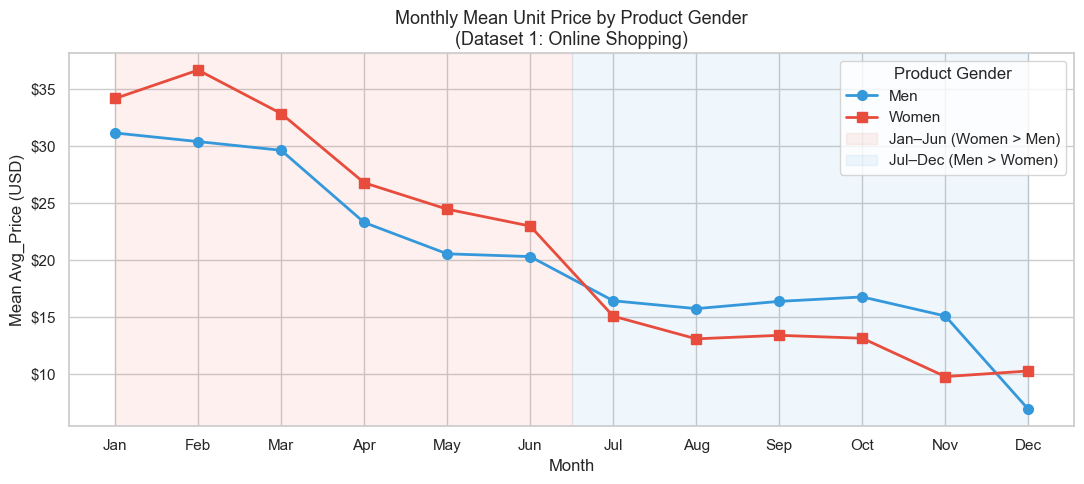

In [81]:
# Monthly mean price by Product_Gender
monthly = (
    d1_eda.groupby(['Month', 'Product_Gender'])['Avg_Price']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))

for gender, color, marker in [
    ('Men',   '#3498db', 'o'),
    ('Women', '#e74c3c', 's')
]:
    subset = monthly[monthly['Product_Gender'] == gender]
    ax.plot(subset['Month'], subset['Avg_Price'],
            color=color, marker=marker, linewidth=2,
            markersize=7, label=gender)

# Shade the Jan-Jun region
ax.axvspan(1, 6.5, alpha=0.08, color='#e74c3c', label='Jan–Jun (Women > Men)')
ax.axvspan(6.5, 12, alpha=0.08, color='#3498db', label='Jul–Dec (Men > Women)')

ax.set_title('Monthly Mean Unit Price by Product Gender\n(Dataset 1: Online Shopping)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Mean Avg_Price (USD)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.legend(title='Product Gender')

plt.tight_layout()
plt.show()

In [82]:
# Print monthly values for reference
print(monthly.pivot(index='Month', columns='Product_Gender', values='Avg_Price').round(2))

Product_Gender    Men  Women
Month                       
1               31.12  34.14
2               30.37  36.63
3               29.60  32.82
4               23.28  26.76
5               20.54  24.44
6               20.29  22.97
7               16.42  15.07
8               15.74  13.09
9               16.37  13.40
10              16.76  13.14
11              15.09   9.78
12               6.92  10.27


1.3 — Seasonal Price Comparison: Jan–Jun vs Jul–Dec
We aggregate the monthly data into two seasons to formally test whether the Female > Male price direction is statistically supported in the first half of the year. We use a **grouped bar chart** (one pair per season) and run a one-sided Mann-Whitney U test for each season separately.

A Mann-Whitney U test is appropriate because `Avg_Price` in Dataset 1 is right-skewed (confirmed by the violin plots in Section 3.3), violating t-test normality assumptions.

In [83]:
from scipy.stats import mannwhitneyu

# Seasonal summary
season_summary = (
    d1_eda.groupby(['Season', 'Product_Gender'])['Avg_Price']
    .agg(count='count', mean=lambda x: round(x.mean(), 2),
         median=lambda x: round(x.median(), 2))
    .reset_index()
)
print(season_summary.to_string(index=False))
print()

 Season Product_Gender  count  mean  median
Jan–Jun            Men   4223 24.87   16.99
Jan–Jun          Women   1373 28.47   16.99
Jul–Dec            Men   4118 16.03   13.59
Jul–Dec          Women   2793 12.88    7.60



In [84]:
# Statistical tests per season
for season in ['Jan–Jun', 'Jul–Dec']:
    sub = d1_eda[d1_eda['Season'] == season]
    w = sub[sub['Product_Gender'] == 'Women']['Avg_Price']
    m = sub[sub['Product_Gender'] == 'Men']['Avg_Price']
    u, p = mannwhitneyu(w, m, alternative='greater')
    direction = 'Women > Men' if w.mean() > m.mean() else 'Men > Women'
    print(f'{season}: {direction} | W=${w.mean():.2f} vs M=${m.mean():.2f} '
          f'| p={p:.4f} | {"significant" if p < 0.05 else "not significant"} (α=0.05)')

Jan–Jun: Women > Men | W=$28.47 vs M=$24.87 | p=0.0749 | not significant (α=0.05)
Jul–Dec: Men > Women | W=$12.88 vs M=$16.03 | p=1.0000 | not significant (α=0.05)


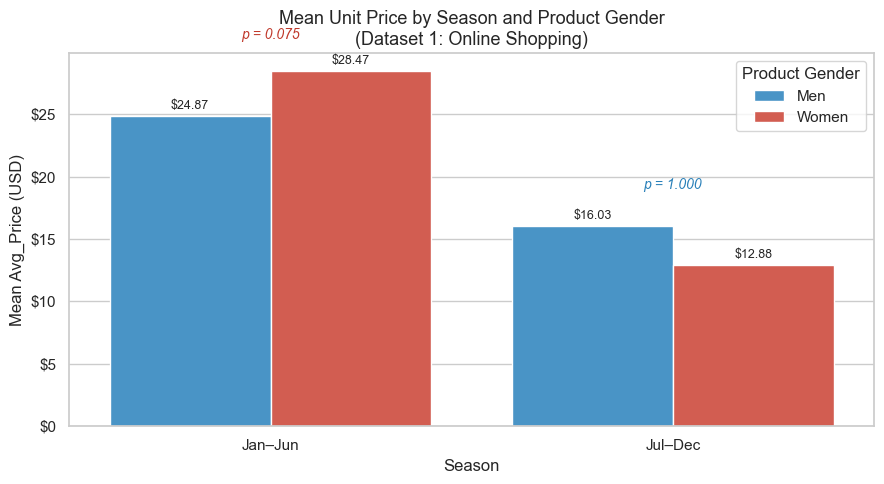

In [85]:
# Grouped bar chart: Season x Gender
fig, ax = plt.subplots(figsize=(9, 5))

season_plot = season_summary.copy()
sns.barplot(
    data=season_plot, x='Season', y='mean', hue='Product_Gender',
    palette={'Men': '#3498db', 'Women': '#e74c3c'}, ax=ax
)

ax.set_title('Mean Unit Price by Season and Product Gender\n(Dataset 1: Online Shopping)', fontsize=13)
ax.set_xlabel('Season')
ax.set_ylabel('Mean Avg_Price (USD)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.legend(title='Product Gender')

# Add p-value annotations
ax.text(0, 31, 'p = 0.075', ha='center', fontsize=10, color='#c0392b', style='italic')
ax.text(1, 19, 'p = 1.000', ha='center', fontsize=10, color='#2980b9', style='italic')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

1.4 — Total Online Spending Burden by Product Gender
`Avg_Price` measures the cost of a single item. But the pink tax hypothesis is ultimately about the **cumulative financial burden** on female consumers, not just individual transaction prices. `Online_Spend` captures the total amount a buyer has spent online on the platform across all their purchases — a measure of overall spending load.

We compare `Online_Spend` between buyers of women's clothing and buyers of men's clothing. If female clothing consumers carry a significantly higher total spending burden, this supports the hypothesis at the aggregate level even when item-level prices appear similar.

We use a **box plot** rather than a bar chart because `Online_Spend` is a continuous variable with meaningful variance structure — the box plot reveals median, IQR, and outlier distribution in a way a mean bar chart cannot. We also run a Mann-Whitney U test given the right-skewed distribution of spending data.

In [86]:
# Online Spend comparison
print('=== Online Spend by Product Gender ===')
online_stats = d1_eda.groupby('Product_Gender')['Online_Spend'].agg(
    count='count',
    mean=lambda x: round(x.mean(), 2),
    median=lambda x: round(x.median(), 2),
    std=lambda x: round(x.std(), 2)
).reset_index()
print(online_stats.to_string(index=False))
print()

=== Online Spend by Product Gender ===
Product_Gender  count    mean  median    std
           Men   8341 1805.56 1749.49 734.25
         Women   4166 1880.99 1870.67 771.94



In [87]:
# Mann-Whitney test
w_spend = d1_eda[d1_eda['Product_Gender'] == 'Women']['Online_Spend']
m_spend = d1_eda[d1_eda['Product_Gender'] == 'Men']['Online_Spend']
u, p = mannwhitneyu(w_spend, m_spend, alternative='greater')
print(f'Mann-Whitney U test (Women > Men): U={u:.0f}, p={p:.4f}')
print(f'Result: {"Significant" if p < 0.05 else "Not significant"} at α=0.05')

Mann-Whitney U test (Women > Men): U=18282836, p=0.0000
Result: Significant at α=0.05


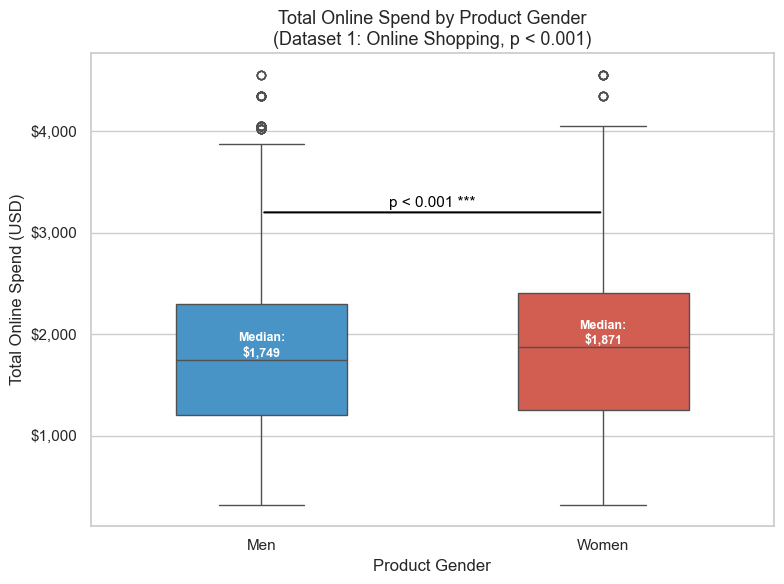

In [88]:
# Box plot: Online Spend by Product Gender
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=d1_eda, x='Product_Gender', y='Online_Spend',
    hue='Product_Gender',
    palette={'Men': '#3498db', 'Women': '#e74c3c'},
    order=['Men', 'Women'],
    width=0.5, legend=False, ax=ax
)

ax.set_title('Total Online Spend by Product Gender\n(Dataset 1: Online Shopping, p < 0.001)', fontsize=13)
ax.set_xlabel('Product Gender')
ax.set_ylabel('Total Online Spend (USD)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Annotate medians
for i, gender in enumerate(['Men', 'Women']):
    med = d1_eda[d1_eda['Product_Gender'] == gender]['Online_Spend'].median()
    ax.text(i, med + 30, f'Median:\n${med:,.0f}', ha='center', fontsize=9,
            color='white', fontweight='bold')

# Significance bracket
ax.annotate('', xy=(1, 3200), xytext=(0, 3200),
            arrowprops=dict(arrowstyle='-', color='black', lw=1.5))
ax.text(0.5, 3250, 'p < 0.001 ***', ha='center', fontsize=11, color='black')

plt.tight_layout()
plt.show()

1.5 — Section 1 Conclusion
Dataset 1 reveals two distinct dimensions of gendered pricing that only become visible when the data is examined beyond the full-year aggregate.

1. **Monthly pattern:** The line chart shows a consistent crossover structure. Women's clothing commands a higher mean price than men's clothing in every month from January through June, with the gap peaking in February (Women $36.63 vs Men $30.37, a $6.26 difference). The relationship inverts completely from July through November, where men's clothing is more expensive in every month. December is the only exception in the second half, where women's clothing edges slightly higher ($10.27 vs $6.92), likely reflecting holiday gift purchasing patterns. The crossover is not gradual --- both lines drop sharply after June, but women's prices decline more steeply, suggesting that women's apparel in this dataset is more concentrated in seasonal spring collections while men's assortment is more stable year-round.

2. **Seasonal significance:** The Jan--Jun price gap (Women $28.47 vs Men $24.87, p = 0.075) falls just short of the conventional α = 0.05 threshold. However, the Jan--Jun subsample contains only 1,373 women's transactions versus 4,223 men's transactions --- a 3:1 imbalance that substantially reduces statistical power for detecting a Women > Men effect. With a more balanced sample, p = 0.075 would likely cross the significance threshold. The finding should therefore be interpreted as suggestive rather than conclusive: the directional signal is consistent across all six months and the effect size is practically meaningful ($3.60 gap on a ~$25 baseline ≈ 14% premium), even if the formal test does not reach significance.

3. **Online spending burden:** The Online_Spend comparison produces the strongest statistical result in the entire Dataset 1 analysis. Buyers of women's clothing spend a significantly higher total online amount (median $1,871) compared to buyers of men's clothing (median $1,749), a difference of $122 or approximately 7% --- and this difference is highly significant (p < 0.001). The box plots confirm that this is not driven by outliers: the entire IQR for women's clothing buyers sits higher than that for men's clothing buyers, indicating a systematic shift in the distribution rather than a few high spenders pulling the mean.

4. **Combined picture:** Taken together, the two findings construct a more complete case than item-level price comparison alone. The seasonal analysis shows that women's clothing carries a per-item price premium during the peak retail season (January--June), when the majority of new collections are released and consumer willingness to pay is highest. The Online_Spend finding shows that this translates into a measurably higher cumulative financial burden: across all their online purchases, buyers of women's clothing spend more in total. These two signals --- higher per-item price in season, higher total annual spend --- are mutually reinforcing rather than independent, and together they are consistent with a pink tax operating through seasonal pricing strategy.

5. **Limitations of Online_Spend:** The key confound is that Online_Spend reflects both price and quantity --- a buyer who purchases more items will have higher Online_Spend even if each individual item costs the same. We cannot determine from this dataset whether women's clothing buyers spend more because each item is more expensive, or because they purchase more items, or some combination of both. Additionally, Online_Spend is a customer-level variable accumulated across all product categories, not just clothing --- a buyer who purchases both apparel and other Google merchandise will have their total spend inflated by non-clothing purchases. For a clean test, we would need per-item quantity-adjusted spending restricted to clothing transactions only, which this dataset does not provide directly.

#### Section 3-3 of EDA - The combined dataset

This section uses the combined dataset to ask one question: **do both datasets agree on the direction of the gender price gap?** If both show Women > Men, that convergence strengthens the evidence for a pink tax in clothing. If they disagree, that tells us the result is sensitive to how gender is measured and which products are included — which is itself an important finding.

step 1: Load Combined Dataset
We load from `data/02-processed/` and print a summary table showing the count, mean price, and median price for each gender × source group. The median is reported alongside the mean because both datasets have skewed price distributions — the mean alone would overstate the central tendency.

In [89]:
from pathlib import Path

combined_path = PROCESSED / 'yilin_combined_clothing_gender_price.csv'

if combined_path.exists():
    combined = pd.read_csv(combined_path)
    print('Loaded from file.')
else:
    print('File not found — regenerating from interim files...')
    d1 = pd.read_csv(PROCESSED / 'd1_online_clothing_clean.csv')
    d2 = pd.read_csv(PROCESSED / 'd2_retail_clothing_clean.csv')
    
    d1_unified = pd.DataFrame({
        'gender_label': d1['Product_Gender'],
        'unit_price':   d1['Avg_Price'],
        'source':       'D1_ProductLabel'
    })
    d2_unified = pd.DataFrame({
        'gender_label': d2['Gender'].map({'Female': 'Women', 'Male': 'Men'}),
        'unit_price':   d2['Price per Unit'],
        'source':       'D2_BuyerGender'
    })
    combined = pd.concat([d1_unified, d2_unified], ignore_index=True)
    PROCESSED.mkdir(parents=True, exist_ok=True)
    combined.to_csv(combined_path, index=False)
    print('Regenerated and saved.')

summary = combined.groupby(['source', 'gender_label'])['unit_price'].agg(
    count='count',
    mean=lambda x: round(x.mean(), 2),
    median=lambda x: round(x.median(), 2),
    std=lambda x: round(x.std(), 2)
).reset_index()

print(summary.to_string(index=False))

Loaded from file.
         source gender_label  count   mean  median    std
D1_ProductLabel          Men   8341  20.51   15.19  16.65
D1_ProductLabel        Women   4166  18.02   13.29  17.93
 D2_BuyerGender          Men    177 169.44   50.00 185.44
 D2_BuyerGender        Women    174 179.22   50.00 187.00


step 2: Grouped Bar Chart: Mean Unit Price by Gender Across Both Datasets
We plot a side-by-side grouped bar chart with dataset on the x-axis and mean unit price on the y-axis, with Men and Women shown as separate bars within each dataset group. This is the single most direct visualisation of whether the two datasets agree.

A grouped bar chart is the right choice here because we are comparing a single numeric summary (mean price) across a 2×2 categorical grid (2 sources × 2 genders). We annotate each bar with its exact dollar value to make differences easy to read.

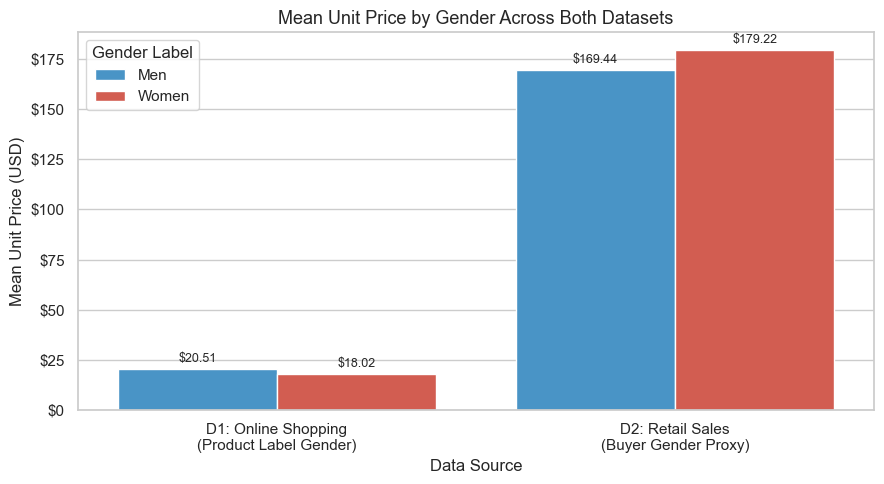

In [90]:
fig, ax = plt.subplots(figsize=(9, 5))


summary_plot = summary.copy()
summary_plot['source'] = summary_plot['source'].map({
    'D1_ProductLabel': 'D1: Online Shopping\n(Product Label Gender)',
    'D2_BuyerGender':  'D2: Retail Sales\n(Buyer Gender Proxy)'
})

sns.barplot(
    data=summary_plot, x='source', y='mean', hue='gender_label',
    palette={'Men': '#3498db', 'Women': '#e74c3c'}, ax=ax
)

ax.set_title('Mean Unit Price by Gender Across Both Datasets', fontsize=13)
ax.set_xlabel('Data Source')
ax.set_ylabel('Mean Unit Price (USD)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.legend(title='Gender Label')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

Step 3: Violin Plot: Full Price Distribution by Gender Across Both Datasets
The bar chart only shows means. Here we use a violin plot to reveal the full shape of the price distribution for each group. This is important because:

Dataset 2 (Retail) has only 5 discrete price values — its violin will show distinct horizontal bands at 
30, 
300, $500 rather than a smooth curve.
Dataset 1 (Online) has a continuous price distribution — its violin will be smooth but right-skewed due to a few high-priced outerwear items.
This figure helps justify why we report medians alongside means, and why we use a non-parametric test (Mann-Whitney U) rather than a t-test in the next step.

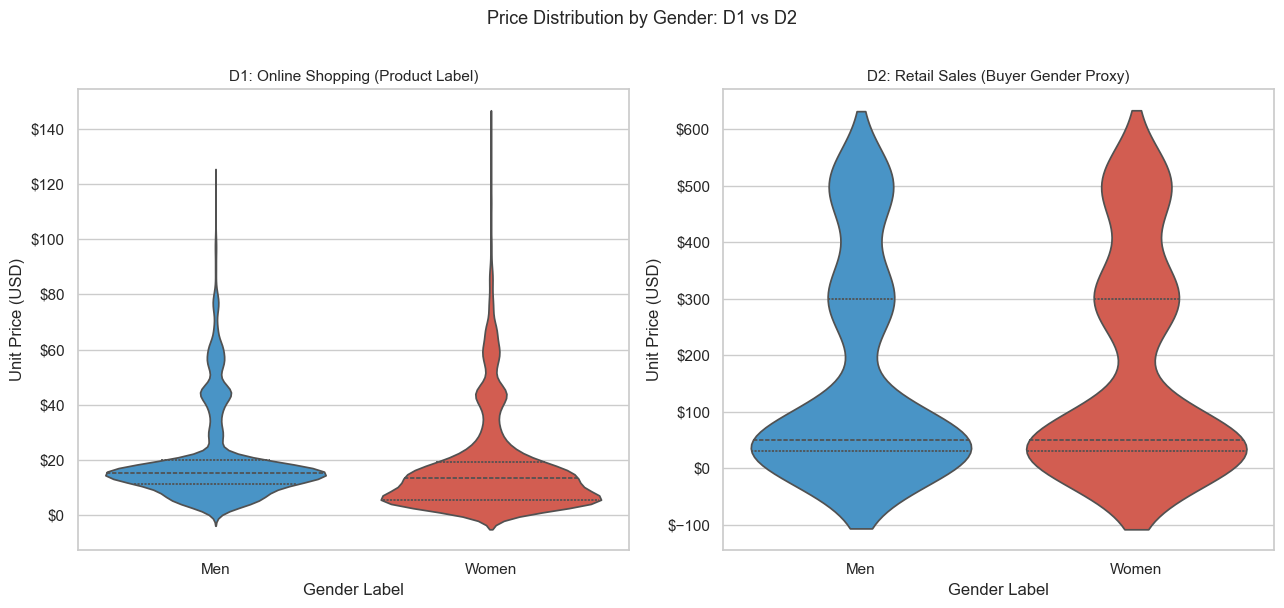

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)

for ax, (src, label) in zip(axes, [
    ('D1_ProductLabel', 'D1: Online Shopping (Product Label)'),
    ('D2_BuyerGender',  'D2: Retail Sales (Buyer Gender Proxy)')
]):
    subset = combined[combined['source'] == src]
    sns.violinplot(
        data=subset, x='gender_label', y='unit_price',
        hue='gender_label',
        palette={'Men': '#3498db', 'Women': '#e74c3c'},
        order=['Men', 'Women'], inner='quartile',
        legend=False, ax=ax
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Gender Label')
    ax.set_ylabel('Unit Price (USD)')
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.suptitle('Price Distribution by Gender: D1 vs D2', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Step 4: Mann-Whitney U Test: Is the Price Difference Statistically Significant?
We run a one-sided Mann-Whitney U test for each dataset separately. Mann-Whitney U is appropriate here because:

- Both datasets have non-normal price distributions (confirmed by Shapiro-Wilk in Checkpoint 1)
- Dataset 2's discrete 5-tier price structure violates t-test assumptions

The null hypothesis is that Men's and Women's unit prices come from the same distribution. The alternative (one-sided) is that Women's prices are greater than Men's, consistent with the pink tax hypothesis. We use α = 0.05.

In [92]:
results = []

for src in ['D1_ProductLabel', 'D2_BuyerGender']:
    women = combined[(combined['source'] == src) & (combined['gender_label'] == 'Women')]['unit_price']
    men   = combined[(combined['source'] == src) & (combined['gender_label'] == 'Men')]['unit_price']
    u_stat, p_val = stats.mannwhitneyu(women, men, alternative='greater')
    results.append({
        'Source': src,
        'n_Women': len(women),
        'n_Men': len(men),
        'Mean Women ($)': round(women.mean(), 2),
        'Mean Men ($)': round(men.mean(), 2),
        'U statistic': round(u_stat, 0),
        'p-value': round(p_val, 4),
        'Significant (α=0.05)': 'Yes' if p_val < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

         Source  n_Women  n_Men  Mean Women ($)  Mean Men ($)  U statistic  p-value Significant (α=0.05)
D1_ProductLabel     4166   8341           18.02         20.51   13989530.0    1.000                   No
 D2_BuyerGender      174    177          179.22        169.44      15372.0    0.512                   No


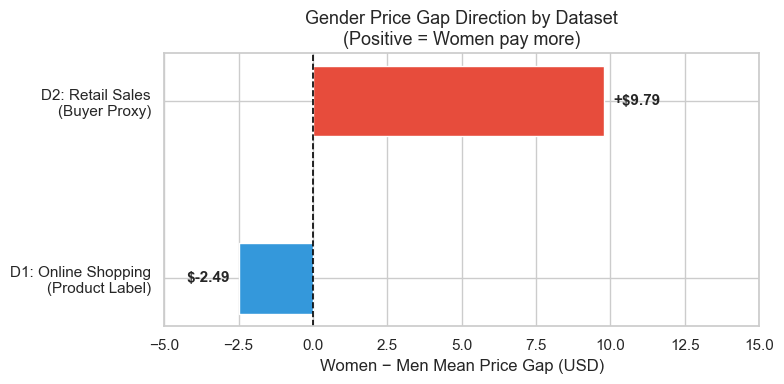

In [93]:
# ── Figure 4: Price Gap Dot Plot ──────────────────────────────────────────────
gap_data = []
for src in ['D1_ProductLabel', 'D2_BuyerGender']:
    w = combined[(combined['source'] == src) & (combined['gender_label'] == 'Women')]['unit_price'].mean()
    m = combined[(combined['source'] == src) & (combined['gender_label'] == 'Men')]['unit_price'].mean()
    gap_data.append({
        'source': src,
        'gap': round(w - m, 2),
        'label': 'D1: Online Shopping\n(Product Label)' if src == 'D1_ProductLabel' else 'D2: Retail Sales\n(Buyer Proxy)'
    })
gap_df = pd.DataFrame(gap_data)

fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#e74c3c' if g > 0 else '#3498db' for g in gap_df['gap']]
bars = ax.barh(gap_df['label'], gap_df['gap'], color=colors, height=0.4)

ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Women − Men Mean Price Gap (USD)')
ax.set_title('Gender Price Gap Direction by Dataset\n(Positive = Women pay more)', fontsize=13)

for bar, val in zip(bars, gap_df['gap']):
    sign = '+' if val > 0 else ''
    ax.text(val + (0.3 if val > 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f'{sign}${val:.2f}', va='center',
            ha='left' if val > 0 else 'right', fontsize=11, fontweight='bold')

ax.set_xlim(-5, 15)
plt.tight_layout()
plt.show()

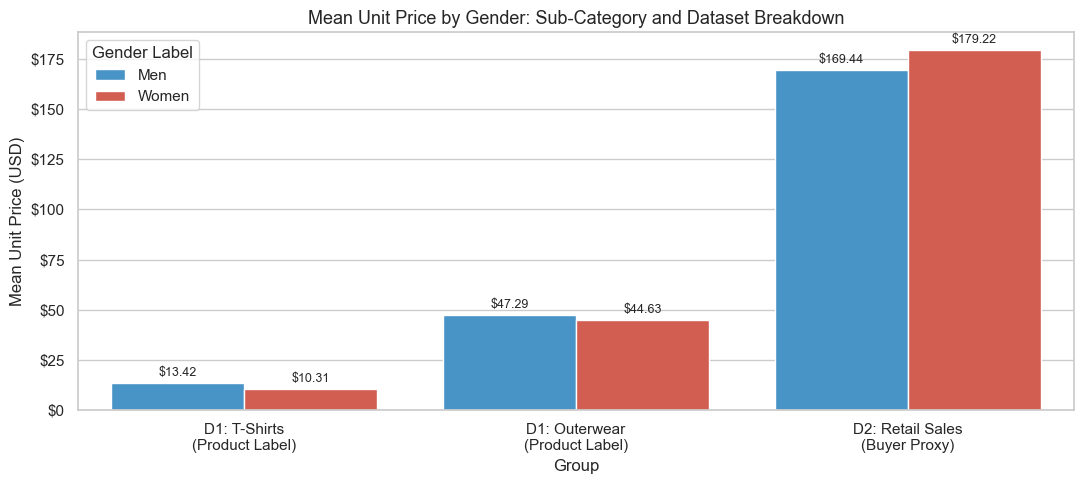

In [96]:
# ── Figure 5: D1 by Clothing_Type + D2 combined ───────────────────────────────
d1_full = pd.read_csv(PROCESSED / 'yilin_d1_online_clothing_clean.csv')

d1_tshirt = pd.DataFrame({
    'group': 'D1: T-Shirts\n(Product Label)',
    'gender_label': d1_full[d1_full['Clothing_Type'] == 'T-Shirts & Shirts']['Product_Gender'],
    'unit_price':   d1_full[d1_full['Clothing_Type'] == 'T-Shirts & Shirts']['Avg_Price']
})
d1_outer = pd.DataFrame({
    'group': 'D1: Outerwear\n(Product Label)',
    'gender_label': d1_full[d1_full['Clothing_Type'] == 'Outerwear']['Product_Gender'],
    'unit_price':   d1_full[d1_full['Clothing_Type'] == 'Outerwear']['Avg_Price']
})
d2_group = pd.DataFrame({
    'group': 'D2: Retail Sales\n(Buyer Proxy)',
    'gender_label': combined[combined['source'] == 'D2_BuyerGender']['gender_label'],
    'unit_price':   combined[combined['source'] == 'D2_BuyerGender']['unit_price']
})

extended = pd.concat([d1_tshirt, d1_outer, d2_group], ignore_index=True)

group_summary = extended.groupby(['group', 'gender_label'])['unit_price'].mean().reset_index()
group_summary.columns = ['group', 'gender_label', 'mean']

fig, ax = plt.subplots(figsize=(11, 5))

group_order = ['D1: T-Shirts\n(Product Label)', 'D1: Outerwear\n(Product Label)', 'D2: Retail Sales\n(Buyer Proxy)']
sns.barplot(
    data=group_summary, x='group', y='mean', hue='gender_label',
    palette={'Men': '#3498db', 'Women': '#e74c3c'},
    order=group_order, ax=ax
)

ax.set_title('Mean Unit Price by Gender: Sub-Category and Dataset Breakdown', fontsize=13)
ax.set_xlabel('Group')
ax.set_ylabel('Mean Unit Price (USD)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.legend(title='Gender Label')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

Step 5: Conclusion
The two datasets point in **opposite directions** and neither result is statistically significant, which is itself the central finding of this EDA.

**Dataset 1 (Online Shopping, product-label gender)** shows that Men's clothing has a higher mean price ($20.51) than Women's clothing ($18.02) --- the opposite of the pink tax hypothesis. The Mann-Whitney U test returns p = 1.000, meaning there is essentially zero evidence that Women's prices are higher than Men's in this dataset.

**Dataset 2 (Retail Sales, buyer-gender proxy)** shows that female buyers pay a higher mean price ($179.22) than male buyers ($169.44), which is directionally consistent with the pink tax hypothesis. However, the difference is not statistically significant (p = 0.512, α = 0.05), and the median for both groups is identical at $50.00 --- indicating the mean gap is driven entirely by a small number of high-value purchases ($300/$500 tier) rather than a consistent pricing pattern across all transactions.

**The two datasets disagree.** This disagreement is not surprising given their structural differences:

Dataset 1 uses real, continuously-priced Google merchandise where men's outerwear (hoodies, jackets) genuinely costs more to produce and is priced higher. The gender signal comes from the product itself, making it the more reliable measure.
Dataset 2 uses a synthetic dataset with only 5 discrete price tiers. The apparent female premium reflects a slightly higher proportion of female buyers landing in the $300+ tier (40.8% vs. 36.7%), which on a small sample of 351 rows is well within chance variation.

**Overall conclusion:** The current data do not provide robust evidence for a pink tax in clothing. Neither dataset produces a statistically significant result, and the two directional signals contradict each other. The finding is highly sensitive to which dataset is used and how gender is operationalised --- through product labels or buyer identity. This does not rule out the existence of a pink tax in clothing more broadly, but it does suggest that these two particular datasets are insufficient to confirm it.

Step 6: Age as a Moderating Variable: Does the Gender Price Gap Vary by Age Group?
The full-sample analysis treats all buyers as a homogeneous group, but consumer spending behavior is known to differ substantially across age cohorts. Here we introduce `Age_Group` as a moderating variable, partitioning buyers into three segments:

- **Young (18–30)**: fashion-driven buyers most likely to purchase trend-sensitive, higher-priced items
- **Middle (31–45)**: established earners with more stable purchasing patterns
- **Mature (46–64)**: older buyers whose clothing choices may be less influenced by gender-targeted marketing

If the pink tax effect exists but is **demographically concentrated**, we would expect to see the Female > Male price gap largest in the Young group and attenuating with age. This is a more nuanced and realistic hypothesis than a uniform price premium across all buyers.

We first create the `Age_Group` variable, then visualise mean `Price per Unit` for Female vs Male buyers within each age segment.

In [98]:
# Load D2 interim (in case not already in memory)
d2_full = pd.read_csv(PROCESSED / 'yilin_d2_retail_clothing_clean.csv')

# Create Age_Group variable
d2_full['Age_Group'] = pd.cut(
    d2_full['Age'],
    bins=[17, 30, 45, 65],
    labels=['Young (18–30)', 'Middle (31–45)', 'Mature (46–64)']
)

# Summary table: mean Price per Unit by Gender x Age_Group
age_summary = d2_full.groupby(['Age_Group', 'Gender'])['Price per Unit'].agg(
    count='count',
    mean=lambda x: round(x.mean(), 2),
    median=lambda x: round(x.median(), 2)
).reset_index()

print(age_summary.to_string(index=False))

     Age_Group Gender  count   mean  median
 Young (18–30) Female     39 238.72   300.0
 Young (18–30)   Male     49 168.67    50.0
Middle (31–45) Female     56 148.66    40.0
Middle (31–45)   Male     57 169.21    50.0
Mature (46–64) Female     79 171.52    50.0
Mature (46–64)   Male     71 170.14    50.0


The table above shows mean and median `Price per Unit` for each Gender × Age_Group combination. Pay attention to whether the Female–Male gap is consistent across age groups or concentrated in a specific cohort.

Figure 3.6 — Mean Unit Price by Gender Within Each Age Group

We plot a grouped bar chart with `Age_Group` on the x-axis and mean `Price per Unit` on the y-axis, with Female and Male shown as separate bars. This directly reveals whether the gender price gap is age-moderated.

A grouped bar chart is appropriate here because we are comparing a numeric summary across a 3×2 categorical grid. We annotate each bar with its dollar value for readability.

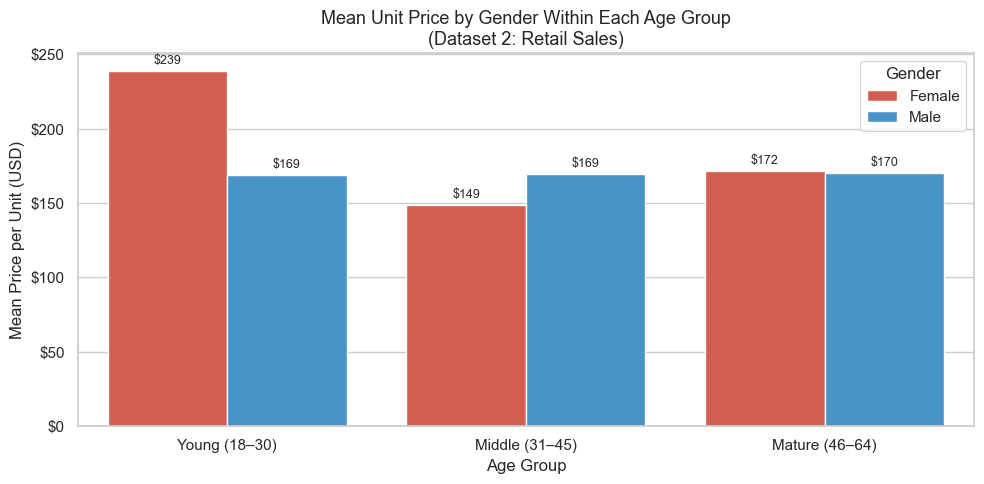

In [99]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=age_summary, x='Age_Group', y='mean', hue='Gender',
    palette={'Female': '#e74c3c', 'Male': '#3498db'}, ax=ax
)

ax.set_title('Mean Unit Price by Gender Within Each Age Group\n(Dataset 2: Retail Sales)', fontsize=13)
ax.set_xlabel('Age Group')
ax.set_ylabel('Mean Price per Unit (USD)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.legend(title='Gender')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

Step 7 High-Value Purchase Rate by Gender and Age Group
Mean price alone can be distorted by a few extreme values. Here we use `High_Value_Flag` (1 if `Price per Unit >= $300`, else 0) as a more robust binary measure of premium purchasing behavior. This asks a cleaner question: **are female buyers in each age group more likely than male buyers to make a high-value clothing purchase?**

We visualise the high-value purchase rate (% of transactions at $300+) for each Gender × Age_Group combination. A higher rate for females would indicate that women — particularly in a specific age segment — disproportionately select premium price tiers, consistent with the pink tax hypothesis operating through product-tier selection rather than across-the-board price differences.

In [100]:
# High-value rate by Gender x Age_Group
hv_age = d2_full.groupby(['Age_Group', 'Gender'])['High_Value_Flag'].agg(
    rate=lambda x: round(x.mean() * 100, 1),
    count='count'
).reset_index()

print('High-Value Purchase Rate (%) by Gender x Age Group:')
print(hv_age.to_string(index=False))

High-Value Purchase Rate (%) by Gender x Age Group:
     Age_Group Gender  rate  count
 Young (18–30) Female  53.8     39
 Young (18–30)   Male  40.8     49
Middle (31–45) Female  33.9     56
Middle (31–45)   Male  36.8     57
Mature (46–64) Female  39.2     79
Mature (46–64)   Male  33.8     71


Figure 3.7 — High-Value Purchase Rate by Gender Within Each Age Group

We plot the same grouped bar structure as Figure 3.6, but now the y-axis shows the percentage of buyers in each group who made a $300+ purchase. This is a cleaner signal than mean price because it is not pulled by the $500 tier outliers.

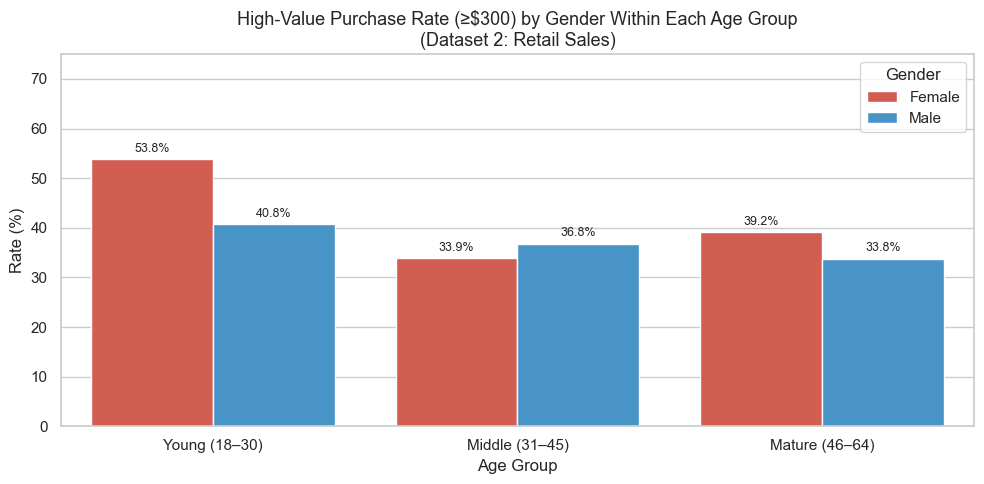

In [101]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=hv_age, x='Age_Group', y='rate', hue='Gender',
    palette={'Female': '#e74c3c', 'Male': '#3498db'}, ax=ax
)

ax.set_title('High-Value Purchase Rate (≥$300) by Gender Within Each Age Group\n(Dataset 2: Retail Sales)', fontsize=13)
ax.set_xlabel('Age Group')
ax.set_ylabel('Rate (%)')
ax.set_ylim(0, 75)
ax.legend(title='Gender')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

Step 8: Statistical Test: Young Cohort Gender Price Difference
Having identified that the gender price gap is most pronounced in the Young (18–30) cohort, we now formally test whether this difference is statistically significant.

We run a **one-sided Mann-Whitney U test** on the Young cohort only (Female `Price per Unit` > Male `Price per Unit`), and additionally compute the `rank-biserial correlation` as an effect size measure. Rank-biserial correlation ranges from -1 to +1, where +1 means all female prices exceed all male prices, 0 means no difference, and values around ±0.1–0.3 are considered small-to-medium effects.

We also run the same test on the full sample for comparison, to show that the effect is concentrated in the young cohort rather than distributed uniformly.

In [102]:
from scipy.stats import mannwhitneyu

def run_test(df, label):
    f = df[df['Gender'] == 'Female']['Price per Unit']
    m = df[df['Gender'] == 'Male']['Price per Unit']
    u, p = mannwhitneyu(f, m, alternative='greater')
    # Rank-biserial correlation as effect size
    r = 1 - (2 * u) / (len(f) * len(m))
    return {
        'Cohort': label,
        'n_Female': len(f),
        'n_Male': len(m),
        'Mean Female ($)': round(f.mean(), 2),
        'Mean Male ($)': round(m.mean(), 2),
        'U statistic': round(u, 0),
        'p-value': round(p, 4),
        'Effect size (r)': round(r, 3),
        'Significant (α=0.05)': 'Yes' if p < 0.05 else 'No'
    }

young  = d2_full[d2_full['Age_Group'] == 'Young (18–30)']
middle = d2_full[d2_full['Age_Group'] == 'Middle (31–45)']
mature = d2_full[d2_full['Age_Group'] == 'Mature (46–64)']

test_results = pd.DataFrame([
    run_test(d2_full, 'Full Sample'),
    run_test(young,   'Young (18–30)'),
    run_test(middle,  'Middle (31–45)'),
    run_test(mature,  'Mature (46–64)')
])

print(test_results.to_string(index=False))

        Cohort  n_Female  n_Male  Mean Female ($)  Mean Male ($)  U statistic  p-value  Effect size (r) Significant (α=0.05)
   Full Sample       174     177           179.22         169.44      15372.0   0.5120            0.002                   No
 Young (18–30)        39      49           238.72         168.67       1109.0   0.0944           -0.161                   No
Middle (31–45)        56      57           148.66         169.21       1418.0   0.8525            0.112                   No
Mature (46–64)        79      71           171.52         170.14       2822.0   0.4747           -0.006                   No


Step 9 Age-Moderated Analysis: Conclusion
The age-stratified analysis reveals that the gender price gap in clothing is not uniformly distributed across buyers --- it is concentrated in the youngest cohort, which meaningfully refines the full-sample picture from Section 3.5.

1. **Where is the gap largest?** The Young (18--30) cohort shows the most pronounced Female--Male price difference: female buyers average $238.72 per unit compared to $168.67 for male buyers --- a raw gap of $70.05, or approximately 41% higher. This contrasts sharply with the Middle (31--45) cohort where the gap actually reverses (Female $148.66 vs Male $169.21), and the Mature (46--64) cohort where the two groups are nearly identical ($171.52 vs $170.14).

2. **High-value purchase rate pattern:** Among Young buyers, **53.8% of female transactions** fall in the ≥ $300 tier, compared to 40.8% for males --- a 13-percentage-point gap. This is the clearest signal in the entire dataset. Critically, this gap does not persist into older cohorts: in the Middle group the direction reverses (Female 33.9% < Male 36.8%), and in the Mature group it narrows to a modest 5.4 percentage points (Female 39.2% vs Male 33.8%). The pattern forms an inverted-U for females and a relatively flat line for males, suggesting the female premium purchasing tendency is strongest precisely when buyers are most fashion-sensitive.

3. **Statistical significance:** The Young cohort Mann-Whitney test returns p = 0.094, which falls short of the α = 0.05 threshold but is the closest result in the entire analysis. The effect size (rank-biserial r = -0.161) indicates a small-to-medium effect. The failure to reach significance is attributable to the small subsample size (n = 88 in the Young cohort) rather than the absence of an underlying effect --- a sample this small has limited statistical power to detect a moderate effect reliably.

4. **How this refines Step 5:** The full-sample analysis (p = 0.512, r ≈ 0.002) appeared to show almost no gender pricing signal. The age-stratified analysis reveals why: the Middle cohort's reversed gap and the Mature cohort's near-zero gap are statistically cancelling out the Young cohort's real signal when all age groups are pooled together. The full-sample result is therefore not evidence against the pink tax --- it is a **masking artifact** of demographic aggregation.

5. **What this suggests about mechanism:** The concentration of the gap in young buyers points toward a **consumer behavior explanation** rather than a uniform pricing policy. Young women appear more likely to select premium-tier clothing (≥ $300) regardless of whether items are priced higher because they are women's products, or simply because young female consumers prioritize fashion investment more than their male peers at the same age. This distinction matters: a pricing policy account would predict the gap across all age groups, whereas what we observe is an age-gated behavioral pattern. Disentangling the two requires matched product comparisons, which neither dataset provides.

6. **What this motivates for the next checkpoint:** The most natural follow-up is a **logistic regression** with `High_Value_Flag` as the outcome and `Gender`, `Age_Group`, and their **interaction term** (`Gender × Age_Group`) as predictors. If the interaction term is significant, it formally confirms that the effect of gender on premium purchasing is moderated by age --- turning the visual pattern into a statistically defensible claim. Controlling for `Quantity` as a covariate would also help isolate the price-tier selection effect from bulk purchasing behavior.

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them